In [1]:
from scipy.special import factorial

def ncr(n, r):
    """Calculate the number of combinations (n choose r)."""
    if r < 0 or r > n:
        return 0
    return factorial(n) / (factorial(r) * factorial(n - r))

def npr(n, r):
    """Calculate the number of permutations (n P r)."""
    if r < 0 or r > n:
        return 0
    return factorial(n) / factorial(n - r)

In [3]:
n = 4
r = 2
npr(n, r), ncr(n, r)

(np.float64(12.0), np.float64(6.0))

In [7]:
from scipy.stats import hypergeom
pairs = 2
socks = pairs*2
hypergeom(M=socks-1, n=2, N=1).pmf(1)   # 0.6666...

np.float64(0.6666666666666666)

In [46]:
packs = 2
pieces = 2
N = packs * pieces
K = pieces
n = 2
k = 2
hypergeom(M=N-1, n=2, N=k).pmf(k)   # 0.4

np.float64(0.3333333333333333)

In [51]:
def test(K, N, k, n):
    a = factorial(K) / factorial(k)
    b = factorial(N-K) / factorial(n-k)
    c = factorial(N) / factorial(n)
    return (a*b)/c

In [52]:
N=52
K=4
n=5
k=2
test(K=K, N=N, k=k, n=n).round(4)

np.float64(0.0)

In [ ]:
from math import comb, perm

def hypergeometric_pmf(N: int, K: int, n: int, k: int) -> float:
    """
    Hypergeometric probability mass function.

    N : total population size (e.g. 52 cards)
    K : number of success states in population (e.g. 4 aces)
    n : number of draws (e.g. 5 cards drawn)
    k : number of observed successes (e.g. 2 aces drawn)

    Returns P(X = k)
    """
    return (comb(K, k) * comb(N - K, n - k)) / comb(N, n)


# Example: deck of 52 cards, 4 aces, draw 5, want exactly 2 aces
# p = hypergeometric_pmf(N=52, K=4, n=5, k=2)
# 3 socks, 2 pairs, draw 1 sock, want exactly 1 pair
p = hypergeometric_pmf(N=3, K=2, n=1, k=1)
# p = hypergeometric_pmf(N=5, K=3, n=1, k=1)
print(p)  # 0.03992981808107859

0.6666666666666666


In [68]:
hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.6666666666666666)

In [70]:
N=5
K=3
n=1
k=1
hypergeometric_pmf(N=N, K=K, n=n, k=k), hypergeom(M=N, n=K, N=n).pmf(k)

(0.6, np.float64(0.6000000000000001))

In [58]:
comb(4, 2), factorial(4) / (factorial(2)*factorial(4-2))

(6, np.float64(6.0))

In [54]:
(
    (factorial(4) / factorial(2)) * (factorial(48) / factorial(3)) /
    (factorial(52) / factorial(5))
)

np.float64(3.693785206390249e-05)

In [14]:
socks-1, socks

(5, 6)

In [ ]:
def probability_grouping(n_pairs: int, strict: bool = True) -> float:
    """P(a random shuffle of n_pairs sock-pairs groups perfectly into
    consecutive matching slots), chaining one hypergeom draw per slot.

    strict=True  -> each slot must be the *same original pair*
    strict=False -> each slot just needs one L + one R, any origin
    """
    prob = 1.0
    remaining_pairs = n_pairs
    while remaining_pairs >= 1:
        total_remaining = 2 * remaining_pairs
        M = total_remaining - 1               # pool left after slot's 1st draw
        n = 1 if strict else remaining_pairs   # successes in that pool
        prob *= hypergeom(M=M, n=n, N=1).pmf(1)
        remaining_pairs -= 1
    return prob


np.float64(0.22857142857142865)

In [81]:
hypergeom(M=5, n=3, N=1).pmf(1) * hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.4)

In [82]:
np.prod([3/5, 2/3]).round(4)

np.float64(0.4)

In [83]:
hypergeom(M=7, n=4, N=1).pmf(1) * hypergeom(M=5, n=3, N=1).pmf(1) * hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.22857142857142865)

In [84]:
np.prod([4/7, 3/5, 2/3]).round(4)

np.float64(0.2286)

In [ ]:
hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.16666666666666666)

In [86]:
hypergeom(M=5, n=4, N=1).pmf(1) * hypergeom(M=4, n=2, N=1).pmf(1)

np.float64(0.4000000000000001)

In [87]:
np.prod([4/5, 2/4]).round(4)

np.float64(0.4)

In [73]:
hypergeom(M=5, n=4, N=1).pmf(1) * hypergeom(M=4, n=3, N=1).pmf(1) * hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.4)

In [88]:
np.prod([6/8, 3/7, 4/5, 2/4]).round(4)

np.float64(0.1286)

In [91]:
hypergeom(M=8, n=6, N=1).pmf(1) * hypergeom(M=7, n=3, N=1).pmf(1) * hypergeom(M=5, n=4, N=1).pmf(1) * hypergeom(M=4, n=2, N=1).pmf(1)

np.float64(0.12857142857142861)

In [60]:
hypergeom(M=3, n=2, N=1).pmf(1)

np.float64(0.6666666666666666)

In [94]:
8 % 2, 4 & 2, 9 % 3

(0, 0, 0)

In [24]:
import numpy as np

In [ ]:
np.prod([2/3]).round(4), probability_grouping(n_pairs=2, strict=False).round(4)

(np.float64(0.6667), np.float64(0.6667))

In [27]:
np.prod([3/5, 2/3]).round(4), probability_grouping(n_pairs=3, strict=False).round(4)

(np.float64(0.4), np.float64(0.4))

In [25]:
np.prod([4/7, 3/5, 2/3]).round(4), probability_grouping(n_pairs=4, strict=False).round(4)

(np.float64(0.2286), np.float64(0.2286))

In [29]:
factorial(4), factorial(6)

(np.float64(24.0), np.float64(720.0))

In [31]:
np.prod([4/5, 2/4]), np.prod([4/5, 1/2])

(np.float64(0.4), np.float64(0.4))

In [36]:
n_pairs = 2
socks = 3
prob = 1.0
remaining_pairs = n_pairs
while remaining_pairs >= 1:
    total_remaining = socks * remaining_pairs
    M = total_remaining - 1               # pool left after slot's 1st draw
    n = remaining_pairs   # successes in that pool
    prob *= hypergeom(M=M, n=n, N=1).pmf(1)
    remaining_pairs -= 1
prob

np.float64(0.20000000000000004)

In [37]:
from scipy.stats import multivariate_hypergeom

# 2 packs -> 2 socks of each leg-type (l, m, r) in the population
multivariate_hypergeom.pmf(x=[1,1,1], m=[2,2,2], n=3)   # 0.4


np.float64(0.39999999999999997)

In [38]:
# 3 packs -> 3 socks of each leg-type
multivariate_hypergeom.pmf(x=[1,1,1], m=[3,3,3], n=3)   # 0.3214 (9/28)

np.float64(0.3214285714285715)

In [43]:
np.prod([6/8, 3/7, 4/5, 2/4]), np.prod([4/5, 2/4])

(np.float64(0.12857142857142856), np.float64(0.4))

In [ ]:
def test_idea(packs=2, pieces=2):
    total_pieces = packs * pieces
    prob = 1.0
    while total_pieces>pieces:
        if total_pieces % pieces == 0:
            total_pieces -= 1
        else:
            
            prob *= hypergeom(M=total_pieces, n=pieces, N=1).pmf(1)
            total_pieces -= 1
    return prob

In [96]:
hypergeom(M=3, n=2, N=1).pmf(1), hypergeom(M=3, n=2, N=1).pmf(0)

(np.float64(0.6666666666666666), np.float64(0.3333333333333333))

In [4]:
from scipy.stats import hypergeom

hypergeom(M=3, n=2, N=2).pmf(1)

np.float64(0.6666666666666666)

In [14]:
remains = 4
pieces = 3
remains % pieces, (remains // pieces)+1

(1, 2)

In [ ]:
import numpy as np
from scipy.stats import hypergeom

def packs_pieces(packs=2, pieces=2):
    """This test with packs|pieces:
    Test:
        - packs=2, 3, 4 | pieces=2 -> pass
        - packs=2, 3, 4 | pieces=3 -> pass
        - packs=2, 3, 4 | pieces=4 -> pass
    """
    initial_pieces = packs * pieces
    remaining_pieces = initial_pieces
    prob = 1.0
    while remaining_pieces>pieces:
        if remaining_pieces % pieces == 0:
            remaining_pieces -= 1
        else:
            success = (remaining_pieces % pieces) * ((remaining_pieces // pieces) + 1)
            prob *= hypergeom(M=remaining_pieces, n=success, N=1).pmf(1)
            remaining_pieces -= 1
    return prob

In [26]:
packs_pieces(packs=2, pieces=2), packs_pieces(packs=3, pieces=2), packs_pieces(packs=4, pieces=2), packs_pieces(packs=5, pieces=2)

(np.float64(0.6666666666666666),
 np.float64(0.4),
 np.float64(0.22857142857142865),
 np.float64(0.126984126984127))

In [28]:
pieces = 2
for i in range(2, 6):
    res = packs_pieces(packs=i, pieces=pieces)
    print(f"packs={i}, pieces={pieces}, probability={res:.4f}")

packs=2, pieces=2, probability=0.6667
packs=3, pieces=2, probability=0.4000
packs=4, pieces=2, probability=0.2286
packs=5, pieces=2, probability=0.1270


In [29]:
pieces = 3
for i in range(2, 6):
    res = packs_pieces(packs=i, pieces=pieces)
    print(f"packs={i}, pieces={pieces}, probability={res:.4f}")

packs=2, pieces=3, probability=0.4000
packs=3, pieces=3, probability=0.1286
packs=4, pieces=3, probability=0.0374
packs=5, pieces=3, probability=0.0103


In [30]:
pieces = 4
for i in range(2, 6):
    res = packs_pieces(packs=i, pieces=pieces)
    print(f"packs={i}, pieces={pieces}, probability={res:.4f}")

packs=2, pieces=4, probability=0.2286
packs=3, pieces=4, probability=0.0374
packs=4, pieces=4, probability=0.0053
packs=5, pieces=4, probability=0.0007


In [8]:
from itertools import combinations, product

a = [0, 2, 4, 6, 8]
b = [1, 3, 5, 7, 9]
a_list = list(combinations(a, 3))
b_list = list(combinations(b, 4))


In [9]:
available_combinations = list(product(a_list, b_list))
len(available_combinations), len(a_list) * len(b_list)

(50, 50)

In [22]:
base = {i for i in range(10)}
results = []
for _a, _b in available_combinations:
    proxy = set(_a) | set(_b)
    result = base - proxy
    if sum(result)==15:
        results.append([sorted(i, reverse=True) for i in (_b, _a, list(result))])

In [23]:
len(results), results

(8,
 [[[9, 7, 5, 3], [4, 2, 0], [8, 6, 1]],
  [[9, 7, 5, 1], [6, 2, 0], [8, 4, 3]],
  [[9, 7, 3, 1], [8, 2, 0], [6, 5, 4]],
  [[9, 7, 3, 1], [6, 4, 0], [8, 5, 2]],
  [[9, 5, 3, 1], [8, 4, 0], [7, 6, 2]],
  [[7, 5, 3, 1], [8, 6, 0], [9, 4, 2]],
  [[9, 5, 3, 1], [6, 4, 2], [8, 7, 0]],
  [[7, 5, 3, 1], [8, 4, 2], [9, 6, 0]]])

In [29]:
a = [0, 2, 4, 6, 8]
b = [1, 3, 5, 7, 9]
a_list = [a[i:i+3] for i in range(len(a)-2)]
b_list = [b[i:i+4] for i in range(len(b)-3)]
available_combinations = list(product(a_list, b_list))
len(available_combinations), len(a_list) * len(b_list)

(6, 6)

In [32]:
base = {i for i in range(10)}
results = []
for _a, _b in available_combinations:
    proxy = set(_a) | set(_b)
    result = base - proxy
    if sum(result)==15:
        results.extend([sorted(i, reverse=True) for i in (_b, _a, list(result))])

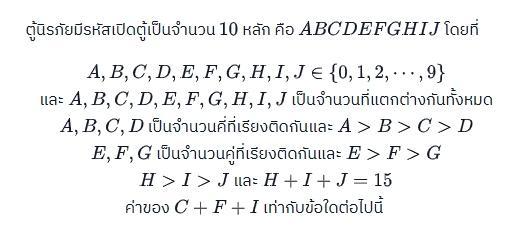

In [45]:
from itertools import chain
import pandas as pd

a = [1, 3, 5, 7, 9]
b = [0, 2, 4, 6, 8]
a_list = [a[i:i+4] for i in range(len(a)-3)]
b_list = [b[i:i+3] for i in range(len(b)-2)]
available_combinations = list(product(a_list, b_list))

base = {i for i in range(10)}
results = []

for _a, _b in available_combinations:
    proxy = set(_a) | set(_b)
    result = base - proxy
    if sum(result)==15:
        results.extend([sorted(i, reverse=True) for i in (_a, _b, list(result))])

flat = list(chain.from_iterable(results))
result_dict = dict(zip(list("ABCDEFGHIJ"), flat))
res = pd.Series(result_dict)

In [46]:
res[['A', 'B', 'C', 'D']], res[['E', 'F', 'G']]

(A    9
 B    7
 C    5
 D    3
 dtype: int64,
 E    4
 F    2
 G    0
 dtype: int64)

In [47]:
res[['H', 'I', 'J']], res[['C', 'F', 'I']]

(H    8
 I    6
 J    1
 dtype: int64,
 C    5
 F    2
 I    6
 dtype: int64)

In [38]:
import pandas as pd
result_dict = dict(zip(list("ABCDEFGHIJ"), flat))
pd.Series(result_dict)

A    9
B    7
C    5
D    3
E    4
F    2
G    0
H    8
I    6
J    1
dtype: int64

In [19]:
list("ABCDEFGHIJ")

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']